In [ ]:
# Tiny Temporal Graph Transformer (TGT) for Power-Flow Forecasting on IEEE-14 
#! works with n-1 topology pertubations

# What this notebook does:
# 1) Load IEEE-14 topology from 'branch_data.parquet'
# 2) Load real time-series loads from 'bus_data.parquet' and flows from 'branch_data.parquet'
# 3) Train a tiny TGT to map past loads -> next-step line flows

import math, numpy as np, numpy.linalg as LA, networkx as nx, matplotlib.pyplot as plt, pandas as pd
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [2]:
#! Set working dir
import os
print(os.getcwd())
os.chdir("../")
print(os.getcwd())

f:\studium\Thesis_Repo\phase1_tgt_model
f:\studium\Thesis_Repo


In [ ]:
#Config
input_data_path = 'data_out/phase2_n1/case14_ieee/raw'
lookback=12
batch_size=64

In [ ]:
# Load Bus and Branch DataFrames
bus_df = pd.read_parquet(f'{input_data_path}/bus_data.parquet')
branch_df = pd.read_parquet(f'{input_data_path}/branch_data.parquet') 

#pivot loads
loads_pivot = bus_df.pivot(index='load_scenario_idx', columns='bus', values='Pd').fillna(0) # X: Input Loads (Active Power 'Pd')
loads_matrix = loads_pivot.values.astype(np.float32)

#Normalize Loads (X)
split_idx = int(0.8 * len(loads_matrix))
X_mean = loads_matrix[:split_idx].mean()
X_std  = loads_matrix[:split_idx].std() + 1e-5
X_norm = (loads_matrix - X_mean) / X_std
print(f"X Normalized. Mean: {X_mean:.4f}, Std: {X_std:.4f}")

# pivot flows
flows_pivot = branch_df.pivot(index='load_scenario_idx', columns='idx', values='pf').fillna(0)
Y_matrix = flows_pivot.values.astype(np.float32)

# Filter inactive lines
status_pivot = branch_df.pivot(index='load_scenario_idx', columns='idx', values='br_status').fillna(0)
mask_matrix = status_pivot.values.astype(bool)

# normalize Y using only active lines
active_values_train = Y_matrix[:split_idx][mask_matrix[:split_idx]]
Y_mean = active_values_train.mean()
Y_std  = active_values_train.std() + 1e-5
Y_norm = (Y_matrix - Y_mean) / Y_std #  Inactive lines will get junk values -> filter later
print(f"Stats (Active Only): Mean={Y_mean:.4f}, Std={Y_std:.4f}")

# ---------------------------------------------------------
#STATIC TOPOLOGY LOOKUP
# ---------------------------------------------------------
# We need to know which Column Index (0..19) maps to which Grid Node (u, v)
# We take the first scenario as the "Master Map"
base_df = branch_df[branch_df['load_scenario_idx'] == 0].sort_values('idx')
# Convert to 0-based indexing for PyTorch
src_nodes = base_df['from_bus'].values.astype(np.int64) - 1
dst_nodes = base_df['to_bus'].values.astype(np.int64) - 1
print(f"Topology Template Ready. {len(src_nodes)} potential lines.")

Topology Loaded: n=14 Nodes, m=20 Edges
shapes: Loads: (8751, 14), Flows: (8751, 20)


In [ ]:

class DynamicIEEE14Dataset(Dataset):
    def __init__(self, x_norm, y_norm, mask, src_nodes, dst_nodes, lookback):
        self.x = x_norm
        self.y = y_norm 
        self.mask = mask 
        
        self.src = src_nodes
        self.dst = dst_nodes
        self.lookback = lookback

    def __len__(self):
        # We lose the first L steps
        return len(self.x) - self.lookback

    def __getitem__(self, idx):
        t = idx + self.lookback

        # input window 
        x_window = torch.tensor(self.x[t-self.lookback : t]).float().t() # (L,n)
        
        # Filter active line target vals ->  Build edge_index for active lines only
        current_mask = self.mask[t] # (m,)
        y_val = torch.tensor(self.y[t][current_mask]).float() # (m_active,)
        curr_src = torch.tensor(self.src[current_mask]) # (m_active,)
        curr_dst = torch.tensor(self.dst[current_mask]) # (m_active,)
        edge_index = torch.stack([curr_src, curr_dst], dim=0) # (2, m_active)
            
        return Data(x=x_window, y=y_val, edge_index=edge_index)

dataset = DynamicIEEE14Dataset(
    X_norm, Y_norm, mask_matrix, 
    src_nodes, dst_nodes, lookback=lookback
)


In [ ]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = torch.utils.data.random_split(dataset, [train_size, val_size])

# PyG DataLoader (Handles the variable graph sizes)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Dataset Created!
Training Data:   X=(6991, 12, 14), Y=(6991, 20)
Validation Data: X=(1748, 12, 14),   Y=(1748, 20)


In [6]:
# Adjacency mask (neighbors + self)
A = np.zeros((n,n), dtype=bool)
for (i,j) in edge_index:
    A[i,j]=True; A[j,i]=True
for i in range(n): A[i,i]=True
A_mask = torch.from_numpy(A).to(device)

class SpatialAttention(nn.Module):
    def __init__(self, d_model=64, n_heads=4):
        super().__init__(); self.h=n_heads; self.dk=d_model//n_heads
        self.q=nn.Linear(d_model,d_model); self.k=nn.Linear(d_model,d_model); self.v=nn.Linear(d_model,d_model); self.o=nn.Linear(d_model,d_model)
    def forward(self, x, mask):
        # x: (B, N, D)
        B,N,D = x.shape; H=self.h; dk=self.dk
        q=self.q(x).view(B,N,H,dk).transpose(1,2)
        k=self.k(x).view(B,N,H,dk).transpose(1,2)
        v=self.v(x).view(B,N,H,dk).transpose(1,2)
        s=(q@k.transpose(-2,-1))/math.sqrt(dk)
        m = mask.unsqueeze(0).unsqueeze(0).expand(B,H,N,N)
        s = s.masked_fill(~m, float('-inf'))
        a = torch.softmax(s, dim=-1)
        out = a@v
        out = out.transpose(1,2).contiguous().view(B,N,D)
        return self.o(out)

class TemporalBlock(nn.Module):
    def __init__(self, d_model=64, n_heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(d_model)
        self.ff  = nn.Sequential(nn.Linear(d_model, 4*d_model), nn.GELU(), nn.Linear(4*d_model, d_model))
        self.ln2 = nn.LayerNorm(d_model)
    def forward(self, x):
        # x: (B, T, D)
        y,_ = self.attn(x,x,x); x=self.ln1(x+y)
        y = self.ff(x); x=self.ln2(x+y); return x

class TinyTGT(nn.Module):
    def __init__(self, n_nodes, n_edges, d_model=64, n_heads=4, n_temporal_layers=2):
        super().__init__(); self.n_nodes=n_nodes; self.n_edges=n_edges
        self.enc = nn.Linear(1, d_model)        # encode scalar load -> embedding
        self.spat = SpatialAttention(d_model, n_heads)
        self.temporal = nn.ModuleList([TemporalBlock(d_model, n_heads) for _ in range(n_temporal_layers)])
        self.edge_mlp = nn.Sequential(nn.Linear(2*d_model, 2*d_model), nn.GELU(), nn.Linear(2*d_model,1))
        src = torch.tensor([i for (i,_) in edge_index], device=device)
        dst = torch.tensor([j for (_,j) in edge_index], device=device)
        self.register_buffer('src', src); self.register_buffer('dst', dst)
    def forward(self, loads_seq, mask):
        # loads_seq: (B, T, N)
        B,T,N = loads_seq.shape
        x = self.enc(loads_seq.reshape(B*T*N,1)).view(B,T,N,-1)   # (B,T,N,D)
        # Spatial attention per time
        x_ = self.spat(x.view(B*T, N, -1), mask).view(B, T, N, -1)
        # Temporal attention per node
        x_bn = x_.permute(0,2,1,3).contiguous().view(B*N, T, -1)
        for layer in self.temporal:
            x_bn = layer(x_bn)
        hT = x_bn[:,-1,:].view(B, N, -1)
        # Edge readout
        h_src = hT[:, self.src, :]; h_dst = hT[:, self.dst, :]
        return self.edge_mlp(torch.cat([h_src, h_dst], dim=-1)).squeeze(-1)  # (B, m)

model = TinyTGT(n_nodes=n, n_edges=m, d_model=64, n_heads=4).to(device)
sum(p.numel() for p in model.parameters())


133377

In [7]:
def to_tensors(X, Y):
    return torch.from_numpy(X).float().to(device), torch.from_numpy(Y).float().to(device)

Xtr_t, Ytr_t = to_tensors(Xtr, Ytr)
Xva_t, Yva_t = to_tensors(Xva, Yva)

opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss() 
batch_size = 128
epochs = 300  # increase for better accuracy

def minibatches(X, Y, bs):
    idx = torch.randperm(X.shape[0])
    for i in range(0, len(idx), bs):
        j = idx[i:i+bs]
        yield X[j], Y[j]

history = {'train_loss': [], 'val_loss': []}

for ep in range(1, epochs+1):
    model.train(); train_loss=0.0
    for xb, yb in minibatches(Xtr_t, Ytr_t, batch_size):
        opt.zero_grad(set_to_none=True)
        yhat = model(xb, A_mask)
        loss = loss_fn(yhat, yb)
        loss.backward(); opt.step()
        train_loss += loss.item()*xb.size(0)
    train_loss /= Xtr_t.size(0)
    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(Xva_t, A_mask), Yva_t).item()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    print(f"Epoch {ep}: train MSE={train_loss:.6f} | val MSE={val_loss:.6f}")

Epoch 1: train MSE=0.553683 | val MSE=0.386121
Epoch 2: train MSE=0.434840 | val MSE=0.300094
Epoch 3: train MSE=0.388047 | val MSE=0.282562
Epoch 4: train MSE=0.373108 | val MSE=0.278012
Epoch 5: train MSE=0.363454 | val MSE=0.269297
Epoch 6: train MSE=0.354312 | val MSE=0.266237
Epoch 7: train MSE=0.349822 | val MSE=0.260250
Epoch 8: train MSE=0.333491 | val MSE=0.256909
Epoch 9: train MSE=0.330466 | val MSE=0.274462
Epoch 10: train MSE=0.321116 | val MSE=0.242947
Epoch 11: train MSE=0.318839 | val MSE=0.267691
Epoch 12: train MSE=0.314888 | val MSE=0.237401
Epoch 13: train MSE=0.310542 | val MSE=0.237943
Epoch 14: train MSE=0.304231 | val MSE=0.268587
Epoch 15: train MSE=0.304864 | val MSE=0.234779
Epoch 16: train MSE=0.304508 | val MSE=0.233995
Epoch 17: train MSE=0.299041 | val MSE=0.239042
Epoch 18: train MSE=0.299653 | val MSE=0.239253
Epoch 19: train MSE=0.295542 | val MSE=0.230803
Epoch 20: train MSE=0.295770 | val MSE=0.242283
Epoch 21: train MSE=0.291472 | val MSE=0.228954
E

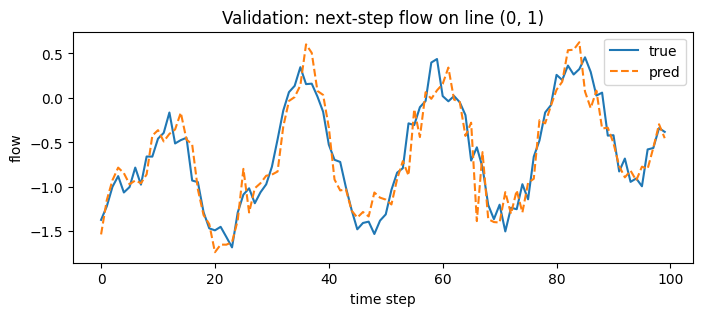

In [8]:
with torch.no_grad():
    pred = model(Xva_t, A_mask).cpu().numpy()

line_id = 0  # pick one line to visualize
true_line = Yva[:, line_id]
pred_line = pred[:, line_id]

plt.figure(figsize=(8,3))
plt.plot(true_line[:100], label='true')
plt.plot(pred_line[:100], label='pred', linestyle='--')
plt.title(f'Validation: next-step flow on line {edge_index[line_id]}')
plt.xlabel('time step'); plt.ylabel('flow'); plt.legend(); plt.show()

In [9]:
print(model)

TinyTGT(
  (enc): Linear(in_features=1, out_features=64, bias=True)
  (spat): SpatialAttention(
    (q): Linear(in_features=64, out_features=64, bias=True)
    (k): Linear(in_features=64, out_features=64, bias=True)
    (v): Linear(in_features=64, out_features=64, bias=True)
    (o): Linear(in_features=64, out_features=64, bias=True)
  )
  (temporal): ModuleList(
    (0-1): 2 x TemporalBlock(
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=256, out_features=64, bias=True)
      )
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (edge_mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): GELU(approximate='none')
  

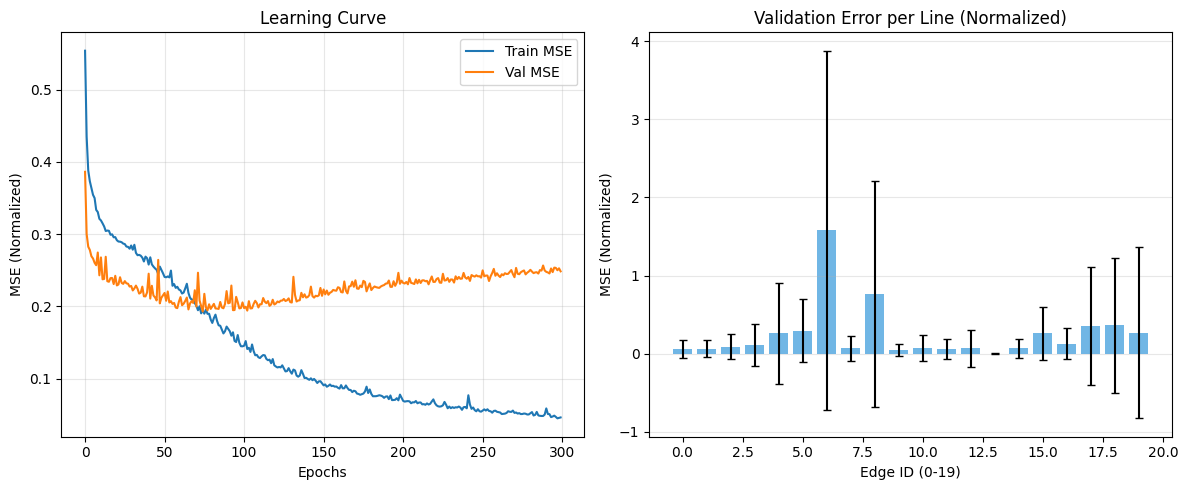

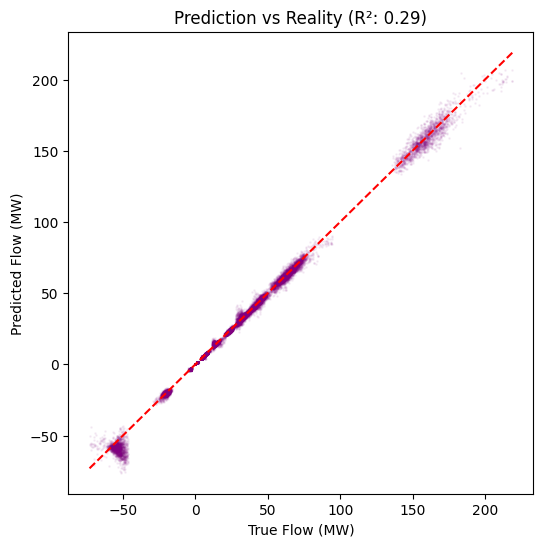

,Edge ID,From,To,Flow %,MSE (Norm),Std (Norm),MSE (Real),Std (Real),Avg (Real),R² Score
0,0,0,1,27.24,0.0652,0.1159,27.75,49.27,159.83,0.8297
1,1,0,4,11.71,0.0618,0.1084,5.12,8.97,68.70,0.8298
2,2,1,2,10.29,0.0891,0.1562,6.18,10.82,60.34,0.7429
6,6,3,4,9.19,1.5768,2.2995,68.86,100.40,-53.91,-3.2923
3,3,1,3,7.64,0.1118,0.2693,4.09,9.86,44.84,0.6639
9,9,4,5,6.33,0.0475,0.0756,1.24,1.97,37.16,0.8643
4,4,1,4,5.46,0.2585,0.6514,5.11,12.87,32.02,0.1935
7,7,3,6,3.99,0.0663,0.1573,0.56,1.34,23.39,0.8103
14,14,6,8,3.99,0.0663,0.1193,0.56,1.02,23.39,0.8103
5,5,2,3,3.46,0.2960,0.4028,2.17,2.95,-20.33,0.3504


In [10]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score

output_dir = 'phase1_tgt_model/outputs/'
# Plot Learning Curves (Normalized)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train MSE')
plt.plot(history['val_loss'], label='Val MSE')
plt.title('Learning Curve')
plt.xlabel('Epochs'); plt.ylabel('MSE (Normalized)')
plt.legend(); plt.grid(True, alpha=0.3)

# calc Final MSE (Global & Per-Edge)
model.eval()
with torch.no_grad():
    pred_norm = model(Xva_t, A_mask)
    true_norm = Yva_t
    sq_errors = (pred_norm - true_norm) ** 2
    edge_mse_mean = sq_errors.mean(dim=0).cpu().numpy() 
    edge_mse_std  = sq_errors.std(dim=0).cpu().numpy()  
    y_pred_np = pred_norm.cpu().numpy()
    y_true_np = true_norm.cpu().numpy()
    
# Plot Per-Edge MSE Bar Chart
plt.subplot(1, 2, 2)
x_pos = np.arange(len(edge_mse_mean))
plt.bar(x_pos, edge_mse_mean, yerr=edge_mse_std, capsize=3, 
        color='#3498db', alpha=0.7, ecolor='black')
plt.xlabel('Edge ID (0-19)')
plt.ylabel('MSE (Normalized)')
plt.title('Validation Error per Line (Normalized)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_path_1 = os.path.join(output_dir, 'learning_and_bar.png')
plt.savefig(save_path_1, dpi=300)
plt.show()

pred_real = (y_pred_np * Y_std) + Y_mean
true_real = (y_true_np * Y_std) + Y_mean
sq_errors_real = (pred_real - true_real) ** 2
edge_mse_real = sq_errors_real.mean(axis=0)
edge_std_real = sq_errors_real.std(axis=0)
edge_avg_real  = true_real.mean(axis=0)
edge_abs_avg = np.abs(true_real).mean(axis=0)
total_system_flow = edge_abs_avg.sum()

r2 = r2_score(true_real, pred_real)

plt.figure(figsize=(6, 6))
plt.scatter(true_real.flatten(), pred_real.flatten(), alpha=0.05, s=1, color='purple')
plt.plot([true_real.min(), true_real.max()], [true_real.min(), true_real.max()], 'r--')
plt.xlabel("True Flow (MW)")
plt.ylabel("Predicted Flow (MW)")
plt.title(f"Prediction vs Reality (R²: {r2:.2f})")
save_path_2 = os.path.join(output_dir, 'scatter_plot.png')
plt.savefig(save_path_2, dpi=300)
plt.show()

#  stats Table
line_report = []
for i in range(len(edge_mse_mean)):
    r2 = r2_score(y_true_np[:, i], y_pred_np[:, i])
    u, v = edge_index[i]
    line_report.append({
        "Edge ID": i,
        "From": u,
        "To": v,
        "Flow %": f"{(edge_abs_avg[i] / total_system_flow) * 100:.2f}",
        "MSE (Norm)": f"{edge_mse_mean[i]:.4f}", 
        "Std (Norm)": f"{edge_mse_std[i]:.4f}",
        "MSE (Real)": f"{edge_mse_real[i]:.2f}",
        "Std (Real)": f"{edge_std_real[i]:.2f}",
        "Avg (Real)": f"{edge_avg_real[i]:.2f}",
        "R² Score": f"{r2:.4f}"
    })
df_results = pd.DataFrame(line_report)
df_results = df_results.sort_values(
    by="Flow %",
    key=lambda s: s.str.rstrip('%').astype(float),
    ascending=False
)
display(df_results)
df_results.to_csv(os.path.join(output_dir, 'model_stats.csv'), index=False, float_format='%.4f')

- plot train and val curves over epochs
- train/val loss (=MSE) +- std (this easily calculatedble?)
- MSE's for every bus
- 

In [1]:
# ---------------------------------------------------------
# CELL 9: Visual Diagnostics of Failed Lines
# ---------------------------------------------------------
bad_lines = [8, 6, 13]  # The ones you identified

plt.figure(figsize=(15, 5))

for i, line_idx in enumerate(bad_lines):
    plt.subplot(1, 3, i+1)
    
    # Get Real MW Data
    truth = true_real[:, line_idx]
    pred  = pred_real[:, line_idx]
    
    # Plot
    plt.plot(truth[:150], label='True', color='black', alpha=0.6)
    plt.plot(pred[:150], label='Pred', color='red', linestyle='--')
    
    # Add Variance info to title
    std_dev = np.std(truth)
    plt.title(f"Line {line_idx} ($R^2$: {line_report[line_idx]['R² Score']:.2f})\nStd Dev: {std_dev:.2f} MW")
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined